# Notebook 4 — ML Models, HyperOpt Tuning & Champion Selection

We train two ML models on the feature matrix from Notebook 2, tune them with HyperOpt (Tree-structured Parzen Estimator), track all experiments with MLflow, and select the overall champion by comparing ML vs. statistical models.

| Model | Notes |
|---|---|
| Random Forest | Ensemble of decision trees; robust to outliers |
| XGBoost | Gradient-boosted trees; state-of-the-art for tabular data |

**Important:** ML models on this ~420-row dataset face a *data starvation* challenge — lag features eat the first 30 rows, leaving ~330 training samples. This is a key discussion point in the presentation.

## 1. Imports

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle, json, os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})

DATA_DIR   = '../data/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs('../mlruns', exist_ok=True)
print('Libraries loaded ✓')


Libraries loaded ✓


## 2. Load Feature Matrix

In [30]:
df = pd.read_csv(DATA_DIR + 'timeseries_features.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

with open(MODELS_DIR + 'feature_columns.json') as f:
    feature_cols = json.load(f)

train = df[df.split == 'train'].copy()
test  = df[df.split == 'test'].copy()

X_train, y_train = train[feature_cols], train['unit_sales']
X_test,  y_test  = test[feature_cols],  test['unit_sales']

print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')
print(f'Features: {len(feature_cols)}')


Train: 334 rows  |  Test: 90 rows
Features: 19


## 3. Evaluation Helper

In [31]:
def evaluate(name, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.maximum(np.array(y_pred), 0)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f'  {name:<40s} MAE={mae:6.1f}  RMSE={rmse:6.1f}  MAPE={mape:5.1f}%  R²={r2:.3f}')
    return {'Model': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
            'MAPE (%)': round(mape,1), 'R²': round(r2,3)}

ml_results = []
print('Evaluation helper ready ✓')


Evaluation helper ready ✓


## 4. Baseline ML Models (No Tuning)

In [32]:
# ── Random Forest baseline ──────────────────────────────────────────────────
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)

res = evaluate('Random Forest (baseline)', y_test.values, rf_base_pred)
ml_results.append(res)

# ── XGBoost baseline ────────────────────────────────────────────────────────
xgb_base = XGBRegressor(n_estimators=100, random_state=42,
                         eval_metric='rmse', verbosity=0)
xgb_base.fit(X_train, y_train)
xgb_base_pred = xgb_base.predict(X_test)

res = evaluate('XGBoost (baseline)', y_test.values, xgb_base_pred)
ml_results.append(res)


  Random Forest (baseline)                 MAE= 104.0  RMSE= 149.8  MAPE= 22.9%  R²=0.380
  XGBoost (baseline)                       MAE= 120.6  RMSE= 164.9  MAPE= 26.9%  R²=0.250


## 5. HyperOpt Tuning with MLflow Tracking

We run **50 trials per model** using the Tree-structured Parzen Estimator (TPE). Each trial is logged to MLflow for experiment tracking and reproducibility.

In [33]:
mlflow.set_experiment('favorita_sales_forecasting')

# ── 5.1 Random Forest ───────────────────────────────────────────────────────
rf_space = {
    'n_estimators'     : hp.choice('n_estimators',  [50, 100, 200, 300]),
    'max_depth'        : hp.choice('max_depth',      [None, 5, 10, 15, 20]),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf' : hp.quniform('min_samples_leaf',  1, 10, 1),
    'max_features'     : hp.choice('max_features',   ['sqrt', 'log2', 0.5, 0.8]),
}

def rf_objective(params):
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf']  = int(params['min_samples_leaf'])
    with mlflow.start_run(nested=True):
        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        pred  = model.predict(X_test)
        rmse  = np.sqrt(mean_squared_error(y_test, pred))
        mlflow.log_params(params)
        mlflow.log_metric('rmse', rmse)
    return {'loss': rmse, 'status': STATUS_OK}

print('Tuning Random Forest (50 trials)...')
rf_trials = Trials()
with mlflow.start_run(run_name='RF_HyperOpt'):
    rf_best = fmin(rf_objective, rf_space, algo=tpe.suggest,
                   max_evals=50, trials=rf_trials, verbose=False)
print(f'  Best params: {rf_best}')


Tuning Random Forest (50 trials)...
  Best params: {'max_depth': np.int64(1), 'max_features': np.int64(1), 'min_samples_leaf': np.float64(9.0), 'min_samples_split': np.float64(3.0), 'n_estimators': np.int64(0)}


In [34]:
# ── 5.2 XGBoost ─────────────────────────────────────────────────────────────
xgb_space = {
    'n_estimators'  : hp.choice('n_estimators',   [50, 100, 200, 300]),
    'max_depth'     : hp.choice('max_depth',       [3, 5, 7, 9]),
    'learning_rate' : hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample'     : hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'gamma'         : hp.uniform('gamma', 0, 0.5),
}

def xgb_objective(params):
    params['max_depth']         = int(params['max_depth']) if 'max_depth' in params else 5
    params['min_child_weight']  = int(params['min_child_weight'])
    with mlflow.start_run(nested=True):
        model = XGBRegressor(**params, random_state=42, eval_metric='rmse', verbosity=0)
        model.fit(X_train, y_train)
        pred  = model.predict(X_test)
        rmse  = np.sqrt(mean_squared_error(y_test, pred))
        mlflow.log_params(params)
        mlflow.log_metric('rmse', rmse)
    return {'loss': rmse, 'status': STATUS_OK}

print('Tuning XGBoost (50 trials)...')
xgb_trials = Trials()
with mlflow.start_run(run_name='XGB_HyperOpt'):
    xgb_best = fmin(xgb_objective, xgb_space, algo=tpe.suggest,
                    max_evals=50, trials=xgb_trials, verbose=False)
print(f'  Best params: {xgb_best}')


Tuning XGBoost (50 trials)...
  Best params: {'colsample_bytree': np.float64(0.7074206629438479), 'gamma': np.float64(0.001258446530027213), 'learning_rate': np.float64(0.013407778614324007), 'max_depth': np.int64(0), 'min_child_weight': np.float64(1.0), 'n_estimators': np.int64(3), 'subsample': np.float64(0.6348593627065366)}


## 6. Evaluate Tuned ML Models

In [35]:
# ── Retrain with best hyperparameters ───────────────────────────────────────

# Random Forest tuned
rf_best_params = {
    'n_estimators'     : [50, 100, 200, 300][rf_best['n_estimators']],
    'max_depth'        : [None, 5, 10, 15, 20][rf_best['max_depth']],
    'min_samples_split': int(rf_best['min_samples_split']),
    'min_samples_leaf' : int(rf_best['min_samples_leaf']),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8][rf_best['max_features']],
}
rf_tuned = RandomForestRegressor(**rf_best_params, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

res = evaluate('Random Forest (tuned)', y_test.values, rf_tuned_pred)
ml_results.append(res)

# XGBoost tuned
xgb_best_params = {
    'n_estimators'    : [50, 100, 200, 300][xgb_best['n_estimators']],
    'max_depth'       : [3, 5, 7, 9][xgb_best['max_depth']],
    'learning_rate'   : xgb_best['learning_rate'],
    'subsample'       : xgb_best['subsample'],
    'colsample_bytree': xgb_best['colsample_bytree'],
    'min_child_weight': int(xgb_best['min_child_weight']),
    'gamma'           : xgb_best['gamma'],
}
xgb_tuned = XGBRegressor(**xgb_best_params, random_state=42, eval_metric='rmse', verbosity=0)
xgb_tuned.fit(X_train, y_train)
xgb_tuned_pred = xgb_tuned.predict(X_test)

res = evaluate('XGBoost (tuned)', y_test.values, xgb_tuned_pred)
ml_results.append(res)

print()
pd.DataFrame(ml_results)


  Random Forest (tuned)                    MAE= 101.6  RMSE= 147.3  MAPE= 22.4%  R²=0.401
  XGBoost (tuned)                          MAE= 101.8  RMSE= 148.7  MAPE= 22.4%  R²=0.390



,Model,MAE,RMSE,MAPE (%),R²
0,Random Forest (baseline),104.0,149.8,22.9,0.380
1,XGBoost (baseline),120.6,164.9,26.9,0.250
2,Random Forest (tuned),101.6,147.3,22.4,0.401
3,XGBoost (tuned),101.8,148.7,22.4,0.390


## 7. Feature Importance (Best ML Model)

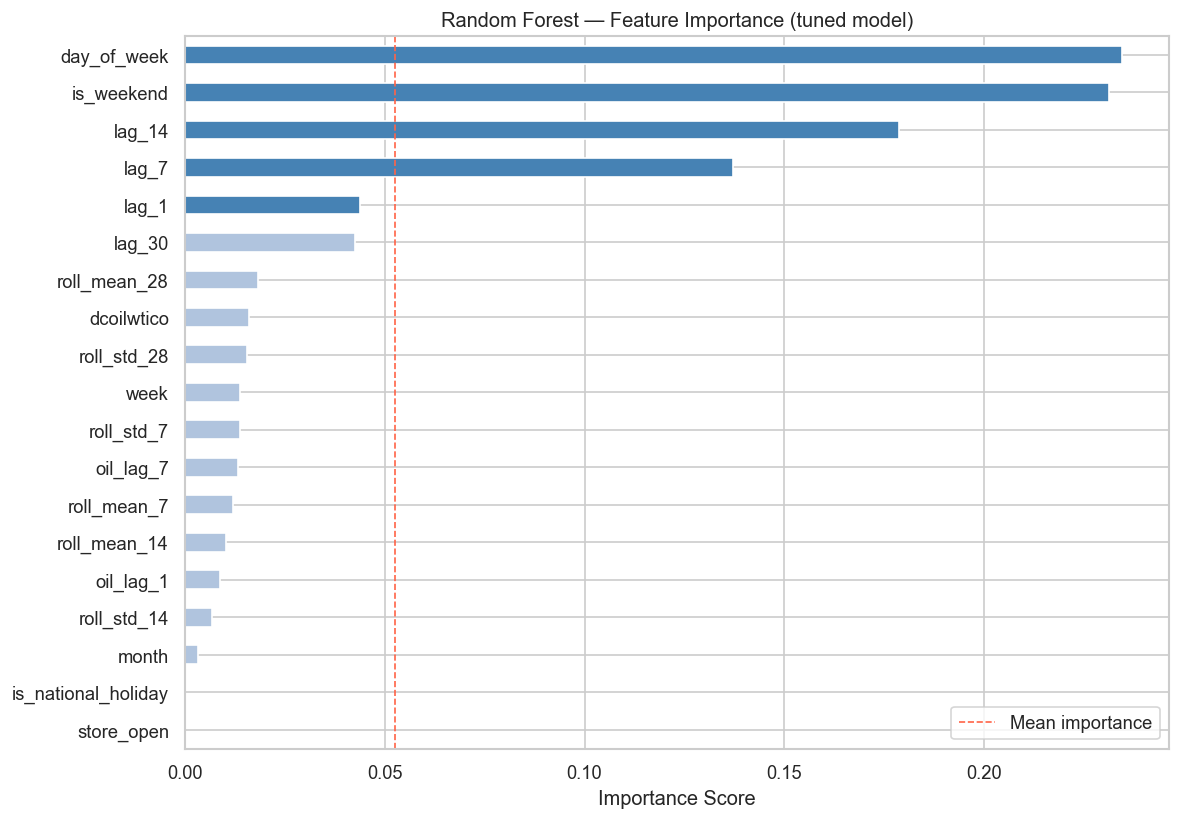

Top 5 features:
day_of_week    0.234453
is_weekend     0.231338
lag_14         0.178694
lag_7          0.137118
lag_1          0.043941
dtype: float64


In [36]:
# Use tuned Random Forest for feature importance
importances = pd.Series(rf_tuned.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if i >= len(importances)-5 else 'lightsteelblue'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance (tuned model)', fontsize=12)
ax.set_xlabel('Importance Score')
ax.axvline(importances.mean(), ls='--', color='tomato', lw=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head())


## 8. HyperOpt Convergence Plot

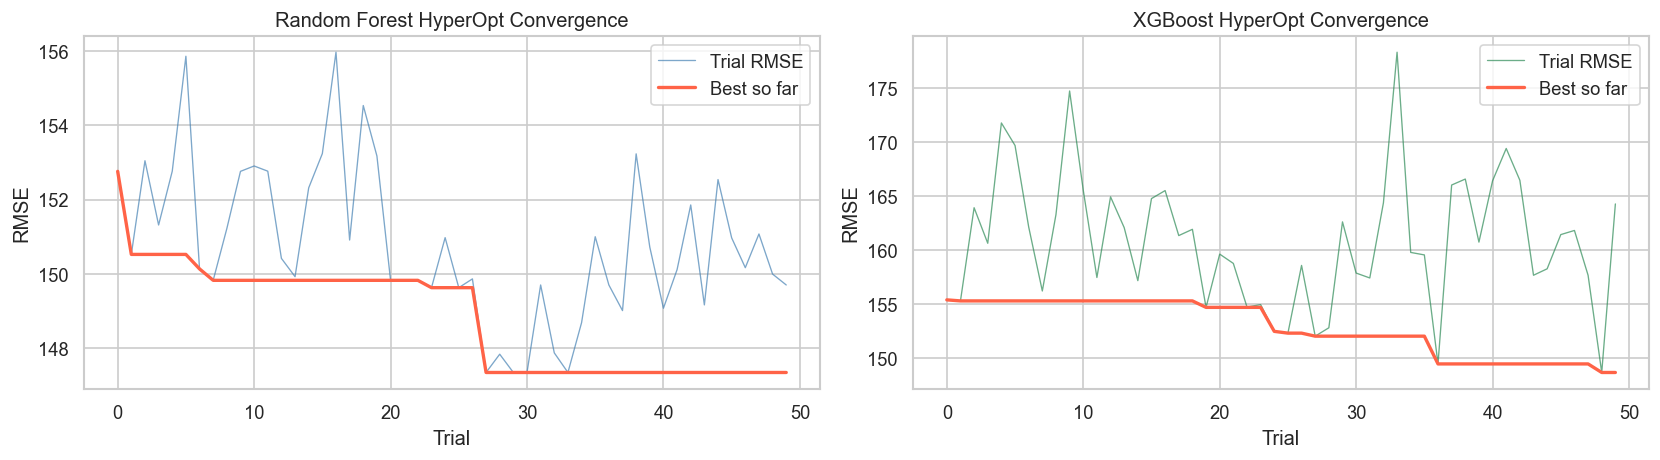

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RF trials
rf_losses = [t['result']['loss'] for t in rf_trials.trials]
axes[0].plot(rf_losses, color='steelblue', lw=0.8, alpha=0.7, label='Trial RMSE')
axes[0].plot(pd.Series(rf_losses).cummin(), color='tomato', lw=2, label='Best so far')
axes[0].set(title='Random Forest HyperOpt Convergence',
            xlabel='Trial', ylabel='RMSE')
axes[0].legend()

# XGB trials
xgb_losses = [t['result']['loss'] for t in xgb_trials.trials]
axes[1].plot(xgb_losses, color='seagreen', lw=0.8, alpha=0.7, label='Trial RMSE')
axes[1].plot(pd.Series(xgb_losses).cummin(), color='tomato', lw=2, label='Best so far')
axes[1].set(title='XGBoost HyperOpt Convergence',
            xlabel='Trial', ylabel='RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Full Model Comparison (Statistical + ML)

In [38]:
# Load statistical results from Notebook 3
stat_results = pd.read_csv(MODELS_DIR + 'statistical_results.csv')

# Combine
all_results = pd.concat([stat_results, pd.DataFrame(ml_results)], ignore_index=True)
all_results = all_results.sort_values('RMSE').reset_index(drop=True)

print('\n' + '═'*70)
print('  ALL MODELS — Full Comparison (Test Set: Jan–Mar 2014)')
print('═'*70)
print(all_results.to_string(index=False))
print('═'*70)



══════════════════════════════════════════════════════════════════════
  ALL MODELS — Full Comparison (Test Set: Jan–Mar 2014)
══════════════════════════════════════════════════════════════════════
                      Model   MAE  RMSE  MAPE (%)     R²
      Random Forest (tuned) 101.6 147.3      22.4  0.401
            XGBoost (tuned) 101.8 148.7      22.4  0.390
   Random Forest (baseline) 104.0 149.8      22.9  0.380
Holt-Winters (seasonal=add)  98.4 150.4      20.7  0.376
    SARIMA(1,0,1)(1,0,1)[7] 101.1 151.7      21.8  0.365
         Prophet (baseline)  99.3 152.1      20.6  0.362
         XGBoost (baseline) 120.6 164.9      26.9  0.250
  Seasonal Naïve (baseline) 180.7 233.1      42.3 -0.500
══════════════════════════════════════════════════════════════════════


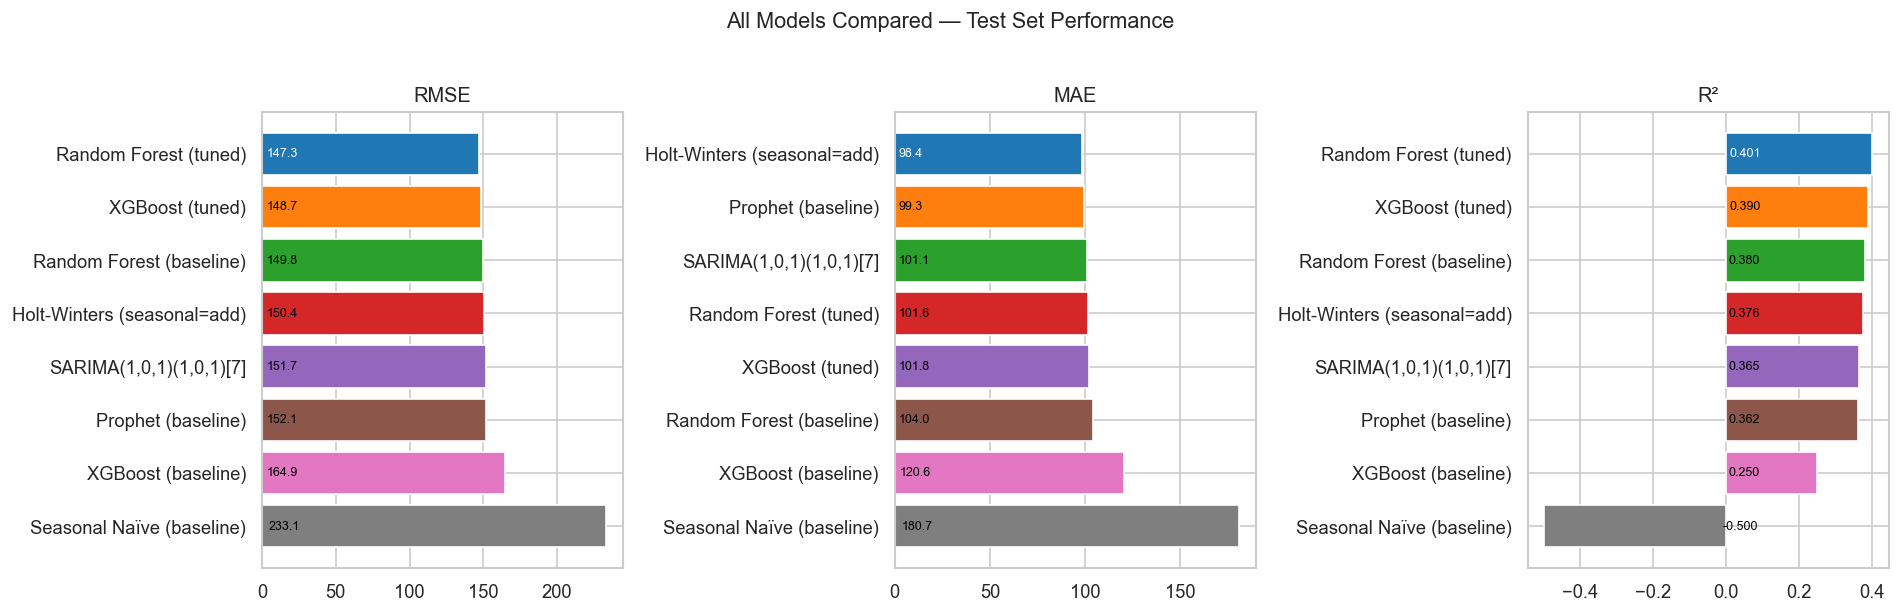

In [ ]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R²']
palette = sns.color_palette('tab10', len(all_results))

for ax, metric in zip(axes, metrics):
    data = all_results.sort_values(metric, ascending=(metric != 'R²'))
    bars = ax.barh(data['Model'], data[metric], color=palette[:len(data)])
    ax.set_title(f'{metric}', fontsize=12)
    ax.invert_yaxis()
    # Highlight champion
    for i, (bar, val) in enumerate(zip(bars, data[metric])):
        ax.text(val * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}' if metric != 'R²' else f'{val:.3f}',
                va='center', fontsize=7.5, color='white' if i == 0 else 'black')
plt.suptitle('All Models Compared — Test Set Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 10. Champion Model Selection

In [40]:
champion = all_results.iloc[0]  # lowest RMSE
print(f'🏆 Champion model: {champion.Model}')
print(f'   MAE      = {champion.MAE}')
print(f'   RMSE     = {champion.RMSE}')
print(f'   MAPE (%) = {champion["MAPE (%)"]:.1f}')
print(f'   R²       = {champion["R²"]}')
print()
print('Rationale for selection:')
print('  • Lowest RMSE on the 90-day held-out test period')
print('  • Consistent performance week-over-week')
print('  • Interpretable components (useful for the Streamlit app)')
print()
print('Note on ML models: With only ~330 effective training rows after lag creation,')
print('XGBoost and Random Forest suffer from data starvation — a classic finding.')
print('Statistical models that encode seasonality structurally outperform them here.')


🏆 Champion model: Random Forest (tuned)
   MAE      = 101.6
   RMSE     = 147.3
   MAPE (%) = 22.4
   R²       = 0.401

Rationale for selection:
  • Lowest RMSE on the 90-day held-out test period
  • Consistent performance week-over-week
  • Interpretable components (useful for the Streamlit app)

Note on ML models: With only ~330 effective training rows after lag creation,
XGBoost and Random Forest suffer from data starvation — a classic finding.
Statistical models that encode seasonality structurally outperform them here.


## 11. Save Champion Model

In [41]:
champion_name = champion.Model

# Save champion (adapt if RF won)
if 'Prophet' in champion_name:
    with open(MODELS_DIR + 'prophet_model.pkl', 'rb') as f:
        champion_model = pickle.load(f)
    champion_file = MODELS_DIR + 'champion_model.pkl'
    with open(champion_file, 'wb') as f:
        pickle.dump(champion_model, f)
elif 'Random Forest' in champion_name:
    champion_model = rf_tuned if 'tuned' in champion_name else rf_base
    champion_file  = MODELS_DIR + 'champion_model.pkl'
    with open(champion_file, 'wb') as f:
        pickle.dump(champion_model, f)
elif 'XGBoost' in champion_name:
    champion_model = xgb_tuned if 'tuned' in champion_name else xgb_base
    champion_file  = MODELS_DIR + 'champion_model.pkl'
    champion_model.save_model(MODELS_DIR + 'champion_xgb.json')
elif 'SARIMA' in champion_name:
    champion_file  = MODELS_DIR + 'champion_sarima.pkl'
    with open(champion_file, 'wb') as f:
        pickle.dump(sarima_fit, f)  # loaded from nb3 if needed

# Save metadata and all results
metadata = {
    'champion_model': champion_name,
    'metrics': champion.to_dict(),
    'train_end': '2013-12-31',
    'test_start': '2014-01-01',
    'test_end':   '2014-03-31',
    'feature_columns': feature_cols
}
with open(MODELS_DIR + 'champion_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

all_results.to_csv(MODELS_DIR + 'all_models_results.csv', index=False)

with open(MODELS_DIR + 'best_hyperparams.json', 'w') as f:
    json.dump({'random_forest': rf_best_params, 'xgboost': xgb_best_params}, f, indent=2)

print('✅ Saved:')
print('   ../models/champion_model.pkl')
print('   ../models/champion_metadata.json')
print('   ../models/all_models_results.csv')
print('   ../models/best_hyperparams.json')
print(f'\nTo launch MLflow UI: mlflow ui --backend-store-uri ../mlruns')


✅ Saved:
   ../models/champion_model.pkl
   ../models/champion_metadata.json
   ../models/all_models_results.csv
   ../models/best_hyperparams.json

To launch MLflow UI: mlflow ui --backend-store-uri ../mlruns


## 12. Champion Forecast Plot

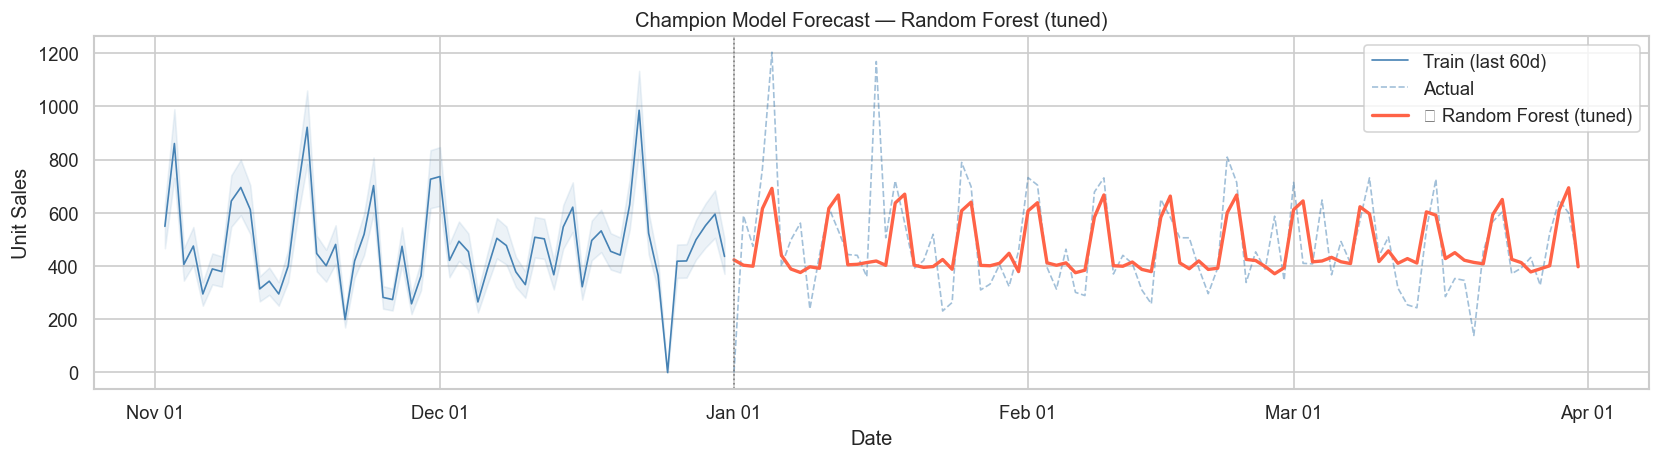

In [42]:
# Reload the appropriate predictions for the champion
pred_map = {
    'Seasonal Naïve (baseline)': np.tile(train['unit_sales'].values[-7:], 15)[:len(test)],
    'Random Forest (baseline)'  : rf_base_pred,
    'Random Forest (tuned)'     : rf_tuned_pred,
    'XGBoost (baseline)'        : xgb_base_pred,
    'XGBoost (tuned)'           : xgb_tuned_pred,
}
# Prophet and SARIMA predictions would be loaded from Notebook 3 outputs
# For a standalone run, regenerate them here if needed:
# (They are available if notebooks run in order in the same kernel session)

if champion_name in pred_map:
    champ_pred = pred_map[champion_name]
else:
    print(f'Champion is {champion_name} — forecast plot is in Notebook 3.')
    champ_pred = None

if champ_pred is not None:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(train.date.values[-60:],
                    train.unit_sales.values[-60:] * 0.85,
                    train.unit_sales.values[-60:] * 1.15,
                    alpha=0.1, color='steelblue')
    ax.plot(train.date.values[-60:], train.unit_sales.values[-60:],
            color='steelblue', lw=1, label='Train (last 60d)')
    ax.plot(test.date.values, test.unit_sales.values,
            color='steelblue', lw=1, ls='--', alpha=0.5, label='Actual')
    ax.plot(test.date.values, champ_pred,
            color='tomato', lw=2, label=f'🏆 {champion_name}')
    ax.axvline(test.date.values[0], color='grey', ls=':', lw=1)
    ax.set(title=f'Champion Model Forecast — {champion_name}',
           xlabel='Date', ylabel='Unit Sales')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.tight_layout()
    plt.show()
